# EDA and Intro to Seaborn  v.ekc

**Seaborn** is another visualization library built on Matplotlib!

Why do we want to learn another package? It is commonly used in EDA to grab patterns and corellations very quickly :) And it is good to know a commonly used package that is used in data science.

| Section | Topic |
|---------|-------|
| 1 | Setup & Warm-Up |
| 2 | Seaborn Basics — Scatter, Line, Bar, Hist |
| 3 | EDA Toolkit — Pairplot, Boxplot, Heatmap |
| 4 | Full EDA Workflow — Covid Dataset |
| 5 | Open Exploration |
| Appendix | Quick Reference |


---
## 1. Setup & Warm-Up

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")
import warnings
warnings.filterwarnings('ignore')


In [ ]:
# Seaborn has built-in datasets — load iris for practice
iris = sns.load_dataset('iris')
iris.head()


### 🔬 Warm-Up — What do you already know?

Before the demo, try to answer:
1. What columns are in `iris`? What type is each?
2. How would you make a basic scatter plot with **Matplotlib**?

*(double-click to write your answers)*


In [ ]:
# Explore the iris dataset — .info(), .describe(), etc.


![iris dataset](https://s3.amazonaws.com/assets.datacamp.com/blog_assets/Machine+Learning+R/iris-machinelearning.png)

---
## 2. Seaborn Basics


| Function | What it does | Key params |
|----------|-------------|------------|
| `sns.scatterplot(data, x, y)` | Scatter plot | `hue`, `style`, `size`, `palette` |
| `sns.lineplot(data, x, y)` | Line plot | `hue` |
| `sns.barplot(data, x, y)` | Bar of means (with CI) | `estimator`, `errorbar` |
| `sns.countplot(data, x)` | Bar of row counts | `hue` |
| `sns.histplot(data, x)` | Histogram | `bins`, `hue`, `kde` |
| `sns.FacetGrid(data, col)` | Facet wrapper | `hue`, then `.map(func, col)` |

**Seaborn vs Matplotlib:** Seaborn functions return an `Axes` object — you can chain `.set_xlim()`, `.set_title()` etc. directly.


In [ ]:
# Basic scatter
sns.scatterplot(data=iris,
                x='petal_length',
                y='petal_width')
plt.show()

In [ ]:
# Map a third variable to color (hue) and shape (style)
sns.scatterplot(data=iris,
                x='petal_length',
                y='petal_width',
                hue='species',
                style='species');


In [ ]:
# Change color palette + adjust axis
ax = sns.scatterplot(data=iris,
                     x='petal_length',
                     y='petal_width',
                     hue='species',
                     palette='colorblind')
ax.set_xlim(0, 8);


In [ ]:
# Facet grid — one panel per species

# First, you need to indialize the grid
g = sns.FacetGrid(iris,
                  col='species',
                  hue='species')

# next, you map the data to the grid
g.map(sns.scatterplot, 'petal_length', 'petal_width');


In [ ]:
# countplot — bar chart of row counts
sns.countplot(data=iris, x='species');


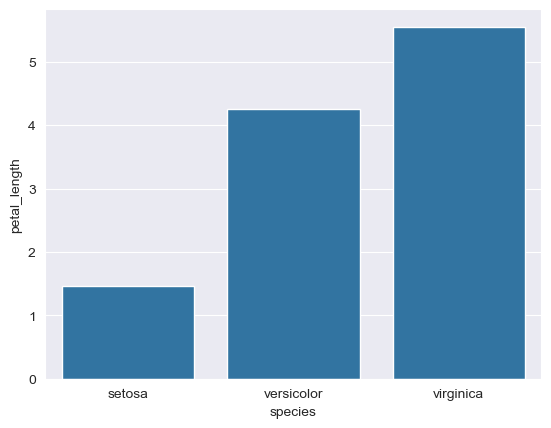

In [65]:
# barplot — mean of a numeric variable per category
sns.barplot(data=iris,
            x='species',
            y='petal_length',
            errorbar=None,
           estimator=np.mean);


In [ ]:
# histogram
sns.histplot(data=iris,
             x='petal_length',
             bins=20);


---
### 🔬 Explore 1 — Seaborn Basics

1. Make a **scatter plot** of `sepal_length` vs `sepal_width`, colored by `species`.  
   Which species seems most separable?

2. Make a **bar plot** of mean `sepal_length` per species (no error bars).  
   Then change the estimator to `np.median` — does it change much?

3. Make a **histogram** of `petal_length` with `kde=True` and `hue='species'`.  
   What does the KDE layer add?

4. Make a **FacetGrid** with one scatter panel per species (`col='species'`), mapping `sepal_length` vs `petal_length`.  
   **Bonus**: Add `row='species'` instead of `col` — what changes?


In [ ]:
# 1. Scatter sepal_length vs sepal_width, colored by species
#   try adding different by adding the attribute:
#              palette='palette_name'




In [ ]:
# 2. Bar plot of mean sepal_length per each species
#      then try median sepal_length per species



In [ ]:
# 3. Histogram with KDE by species
#       what is x? what is y? do you include both??



In [ ]:
# 4. FacetGrid scatter



<details>
<summary>💡 One approach — click to peek</summary>
<br>

*The KDE (kernel density estimate) overlaid on a histogram shows the smooth underlying distribution shape.*

```python
# 1. Scatter sepal dims by species
sns.scatterplot(data=iris,
                x='sepal_length',
                y='sepal_width',
                hue='species',
                palette='Set2');

# 2. Bar mean vs median
sns.barplot(data=iris,
            x='species',
            y='sepal_length',
            errorbar=None);
sns.barplot(data=iris,
            x='species',
            y='sepal_length',
            estimator=np.median,
            errorbar='sd');      # uses standard deviation instead of CI

# 3. Histogram + KDE
sns.histplot(data=iris, x='petal_length', hue='species', kde=True, bins=20);

# 4. FacetGrid
g = sns.FacetGrid(iris, col='species', hue='species')
g.map(sns.scatterplot, 'sepal_length', 'petal_length')
g.add_legend();
```

</details>

---
## 3. EDA Toolkit — Pairplot, Boxplot, Heatmap

### 📋 Board Reference

| Tool | Best for | Key params |
|------|----------|------------|
| `sns.pairplot(data)` | Quick overview of all numeric relationships | `hue` |
| `sns.boxplot(data, x, y)` | Distribution by category, outliers visible | `x`, `y` |
| `sns.heatmap(corr_matrix, annot=True)` | Correlation overview | `annot`, `cmap` |

**EDA workflow:**  
`load → .info() → .describe() → .isna() → .duplicated() → visualize`


In [ ]:
# pairplot — every numeric column vs every other
sns.pairplot(data=iris, hue='species');


In [ ]:
# boxplot — distribution of one column across species
sns.boxplot(data=iris, x='species', y='sepal_width');


In [ ]:
# heatmap of correlations
corrmat = iris.corr(numeric_only=True)
sns.heatmap(data=corrmat, annot=True, cmap='coolwarm');


---
### 🔬 Explore 2 — EDA Toolkit

1. Run `sns.pairplot(iris, hue='species')`. Which **pair of columns** best separates the three species?  
   Write your answer below.

2. Make a **boxplot** of `petal_length` by `species`. Are there any outliers?

3. Make a **heatmap** of the iris correlation matrix.  
   Which two numeric columns are most strongly correlated? Does this make biological sense?

4. **Bonus**: Filter the iris data to `species == 'versicolor'` only, then make a pairplot.  
   How does the pattern change within one species?


In [ ]:
# 1. pairplot — which pair separates best?


**Answer to Q1:** *(double-click to edit)*

*Your answer here*

In [ ]:
# 2. boxplot of petal_length by species


In [ ]:
# 3. heatmap — which columns most correlated?


**Answer to Q3:** *(double-click to edit)*

*Your answer here*

In [ ]:
# 4. Bonus: pairplot for versicolor only


<details>
<summary>💡 One approach — click to peek</summary>
<br>

*Within a single species, correlations often look different than across all species — this is Simpson's Paradox in action!*

```python
# 1. Pairplot
sns.pairplot(iris, hue='species');
# Best separator: petal_length vs petal_width — setosa is clearly separate

# 2. Boxplot
sns.boxplot(data=iris, x='species', y='petal_length');

# 3. Correlation heatmap
corrmat = iris.corr(numeric_only=True)
sns.heatmap(corrmat, annot=True, cmap='coolwarm');
# petal_length and petal_width are most correlated (r≈0.96)

# 4. Bonus: one species only
versi = iris[iris['species'] == 'versicolor']
sns.pairplot(versi);
```

</details>

---
## 4. Full EDA Workflow — Covid Dataset

Now we apply the full workflow to a real-world dataset: **Covid totals by country**.  
Each row is a country with cumulative case/death counts and demographic info.


In [ ]:
covid = pd.read_csv('https://raw.githubusercontent.com/PacktPublishing/Python-Data-Cleaning-Cookbook/master/Chapter05/data/covidtotals.csv')
covid.head()


**Covid dataset columns:**

| Column | Description |
|--------|-------------|
| `iso_code` | 3-letter country code |
| `location` | Country name |
| `total_cases` / `total_deaths` | Cumulative counts |
| `total_cases_pm` / `total_deaths_pm` | Per million population |
| `population`, `pop_density` | Demographics |
| `gdp_per_capita`, `median_age` | Socioeconomic factors |
| `region` | World region |


---
### 🔬 Explore 3 — Full EDA on Covid Data

Work through this structured EDA. Take notes as you go — jot down what surprises you.

**Step 1 — Inspect**


In [ ]:
# covid.info(), covid.describe(), covid.shape


**Step 2 — Check data quality**

In [ ]:
# Check NAs per column, check duplicates


In [ ]:
# Drop columns with NA values (keeps rows intact)
covid_clean = covid.dropna(axis=1)
print(f'Columns before: {covid.shape[1]}, after: {covid_clean.shape[1]}')
covid_clean.shape


**Step 3 — Summarize**

In [ ]:
# a. groupby region to find mean total_deaths_pm
# b. which country has highest death rate?

covid.groupby('region')['total_deaths_pm'].mean()

<details>
<summary>💡 One approach — click to peek</summary>
<br>

```python

# groupby region to find mean total_deaths_pm
covid.groupby('region')['total_deaths_pm'].mean()

# Which country has highest death rate per million?
covid_clean.loc[covid_clean['total_deaths_pm'].idxmax(), 'location']
```

</details>

**Step 4 — Visualize**

In [ ]:
# pairplot on covid_clean numeric columns

sns.pairplot(covid_clean, hue='region')

In [ ]:
# Boxplot: deaths per million by world region
plt.figure(figsize=(5, 6))
sns.boxplot(y='region', x='total_deaths_pm', data=covid_clean)
plt.tight_layout()
plt.show()


In [ ]:
# Correlation heatmap of covid_clean numeric columns


**What did you find?** *(double-click to edit)*

*Write 2-3 observations from your EDA — what patterns or surprises did you see?*


<details>
<summary>💡 One approach — click to peek</summary>
<br>

*median_age and gdp_per_capita tend to correlate with higher deaths per million — a counterintuitive but well-documented pattern.*

```python
# Inspect
print(covid.info())
print(covid.describe())

# Quality
print(covid.isna().sum())
print(covid.duplicated().sum())
covid_clean = covid.dropna(axis=1)

# Summarize
print(covid_clean.groupby('region')['total_deaths_pm'].mean().sort_values(ascending=False))
print(covid_clean.loc[covid_clean['total_deaths_pm'].idxmax(), 'location'])

# Pairplot (may be slow — numeric only)
sns.pairplot(covid_clean.select_dtypes('number'));

# Heatmap
corrmat = covid_clean.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corrmat, annot=True, fmt='.1f', cmap='coolwarm')
plt.title('Covid Dataset Correlations')
plt.tight_layout()
plt.show()
```

</details>

---
## Appendix — Seaborn Quick Reference

```python
import seaborn as sns
sns.set_style("darkgrid")   # whitegrid | dark | white | ticks

# Basic plots
sns.scatterplot(data=df, x='col', y='col2', hue='cat', style='cat', palette='colorblind')
sns.lineplot(data=df, x='col', y='col2', hue='cat')
sns.barplot(data=df, x='cat', y='num', estimator=np.mean, errorbar=None)
sns.countplot(data=df, x='cat')
sns.histplot(data=df, x='num', bins=20, hue='cat', kde=True)

# EDA toolkit
sns.pairplot(data=df, hue='cat')
sns.boxplot(data=df, x='cat', y='num')
sns.heatmap(data=df.corr(numeric_only=True), annot=True, cmap='coolwarm')

# Facets
g = sns.FacetGrid(df, col='cat', hue='cat')
g.map(sns.scatterplot, 'x_col', 'y_col')
g.add_legend()

# EDA workflow
df.info()
df.describe()
df.isna().sum()
df.duplicated().sum()
```

## References
[Medium article](https://medium.com/@arsalan_zafar/bar-plots-in-seaborn-6a81c453e0c4)
